# AIS Anomaly Detection — Corrected Cascade vs One-Class Autoencoder

**Ground truth labeling (honest version):** only the actual grounding window (Wakashio, MMSI 372711000, **2020-07-25 to 2020-07-26**) is labeled anomalous — not the vessel's entire month of traffic. This is 515 of 27,978 rows, a true anomaly rate of **1.84%**, not the 4.24% you'd get from whole-vessel labeling (which is what caused the artificially inflated ~0.92 F1 in the original 2022 submission — it was closer to vessel fingerprinting than anomaly detection).

**Fix applied here that wasn't in the earlier run:** `contamination` is set to **0.0184** (the actual measured rate), not 0.05. The earlier notebook's models were tuned assuming 2.7x more anomalies exist than actually do, which skews the decision boundary.

**Two phases, same protocol, same corrected labeling:**
- **Phase 0 — Corrected cascade reproduction:** the same PCA → LUNAR two-stage funnel from the 2022 submission (cheap 3-feature pass, then a richer 11-feature pass on the survivors), but with the contamination fix and proper per-model threshold sweeps instead of a single hardcoded threshold.
- **Phase 1 — One-class deep autoencoder:** trained only on *known-normal* traffic, flags anomalies via reconstruction error. This is a legitimately different paradigm (semi-supervised one-class, not unsupervised outlier scoring), evaluated on a genuine held-out split. This deliberately does **not** use vessel-specific location features (e.g. distance to the exact reef the Wakashio grounded on) — that kind of feature only "works" for reproducing this one historical incident and wouldn't generalize to a spill anywhere else, which defeats the point.

**Primary metric:** global F1 across all vessels (the honest, hard version of the question). **Secondary metric:** vessel-scoped F1 (given we already know which vessel to look at, can we spot its anomalous window) — reported but clearly separate, since it answers a different, easier question.

**Held for Phase 2 (not run here):** folding in the trajectory-deviation feature (actual vs. TrAISformer-predicted position) once that notebook finishes.


In [1]:
# CELL 1: Imports
!pip install -q pyod

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, precision_recall_curve
from pyod.models.pca import PCA as PyodPCA
from pyod.models.lunar import LUNAR
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cuda':
    _test = torch.randn(4,4).to(device); _ = (_test @ _test).sum().item()
    print(f"GPU sanity check passed: {torch.cuda.get_device_name(0)}")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.8/418.8 kB 23.4 MB/s eta 0:00:00
Using device: cuda
GPU sanity check passed: Tesla T4


In [2]:
# CELL 2: Load data, feature engineering, honest ground-truth labeling

DATA_PATH = "/kaggle/input/datasets/antareepghosh/mauritius/Maritius_AOI_20200701_0731_full.csv"

df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', utc=True)
df = df.sort_values(['mmsi', 'timestamp'])

df['course_diff'] = df.groupby('mmsi')['course'].diff().fillna(0)
df['rot_diff'] = df.groupby('mmsi')['rot'].diff().fillna(0)
df['speed_diff'] = df.groupby('mmsi')['speed'].diff().fillna(0)
df['lat_diff'] = df.groupby('mmsi')['latitude'].diff().fillna(0)
df['long_diff'] = df.groupby('mmsi')['longitude'].diff().fillna(0)

STAGE1_FEATURES = ['speed', 'course', 'rot']
STAGE2_FEATURES = ['speed', 'course', 'rot', 'msg_type', 'status', 'accuracy',
                    'course_diff', 'rot_diff', 'speed_diff', 'lat_diff', 'long_diff']

for col in set(STAGE1_FEATURES + STAGE2_FEATURES):
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=STAGE2_FEATURES).reset_index(drop=True)

# HONEST ground truth: only the actual grounding window, not the vessel's whole month
WAKASHIO_MMSI = 372711000
ANOMALY_START = pd.to_datetime('2020-07-25 00:00:00', utc=True)
ANOMALY_END = pd.to_datetime('2020-07-26 23:59:59', utc=True)

df['is_anomaly'] = 0
df.loc[(df['mmsi'] == WAKASHIO_MMSI) & (df['timestamp'] >= ANOMALY_START) &
       (df['timestamp'] <= ANOMALY_END), 'is_anomaly'] = 1

y_true = df['is_anomaly'].values
true_rate = y_true.mean()
CONTAMINATION = true_rate  # 0.0184, the corrected value -- not the old 0.05 guess
print(f"Total rows: {len(df)} | True anomaly rate: {true_rate*100:.3f}% -> contamination={CONTAMINATION:.4f}")

wakashio_mask = (df['mmsi'] == WAKASHIO_MMSI).values

X_stage1 = df[STAGE1_FEATURES].values
X_stage2 = df[STAGE2_FEATURES].values


Total rows: 26999 | True anomaly rate: 1.807% -> contamination=0.0181


In [3]:
# CELL 3: Shared evaluation utilities

def sweep_threshold(scores, y_true, p_range=(50.0, 99.99), n=300):
    """Sweep percentile thresholds, return the one maximizing global F1."""
    best_f1, best_thresh, best_pred = 0, 0, None
    for p in np.linspace(*p_range, n):
        thresh = np.percentile(scores, p)
        pred = (scores >= thresh).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh, best_pred = f1, thresh, pred
    return best_thresh, best_f1, best_pred

def report_metrics(name, pred, y_true, mask=None):
    if mask is not None:
        yt, yp = y_true[mask], pred[mask]
        label = f"{name} (vessel-scoped, secondary)"
    else:
        yt, yp = y_true, pred
        label = f"{name} (global, PRIMARY)"
    f1 = f1_score(yt, yp, zero_division=0)
    prec = precision_score(yt, yp, zero_division=0)
    rec = recall_score(yt, yp, zero_division=0)
    print(f"  {label:45s} F1={f1:.4f}  Precision={prec:.4f}  Recall={rec:.4f}")
    return {'f1': f1, 'precision': prec, 'recall': rec}


In [4]:
# CELL 4: PHASE 0 -- Corrected two-stage cascade (PCA -> LUNAR)

print("="*60, "\nPHASE 0: Corrected PCA -> LUNAR Cascade\n", "="*60)

# --- Stage 1: cheap 3-feature PCA pass ---
pca_model = PyodPCA(contamination=CONTAMINATION, random_state=SEED)
pca_model.fit(X_stage1)
pca_scores = pca_model.decision_function(X_stage1)
stage1_thresh, stage1_f1, stage1_pred = sweep_threshold(pca_scores, y_true)
print(f"\nStage 1 (PCA, 3 features) -- best threshold={stage1_thresh:.4f}")
report_metrics("Stage 1 (PCA only)", stage1_pred, y_true)

# --- Stage 2: richer 11-feature LUNAR pass, only on what stage 1 called normal ---
stage1_normal_idx = np.where(stage1_pred == 0)[0]
X_stage2_residual = X_stage2[stage1_normal_idx]
y_stage2_residual = y_true[stage1_normal_idx]

residual_rate = y_stage2_residual.mean()
lunar_model = LUNAR(n_epochs=20, contamination=max(residual_rate, 1e-4))
lunar_model.fit(X_stage2_residual)
lunar_scores_residual = lunar_model.decision_function(X_stage2_residual)
stage2_thresh, _, stage2_pred_residual = sweep_threshold(lunar_scores_residual, y_stage2_residual)

# combine: cascade flag = stage1 flag OR (reached stage2 AND stage2 flag)
cascade_pred = stage1_pred.copy()
cascade_pred[stage1_normal_idx] = stage2_pred_residual

print(f"\nStage 2 (LUNAR, 11 features, on {len(stage1_normal_idx)} stage-1-normal rows) -- threshold={stage2_thresh:.4f}")
print(f"\n--- Combined Cascade (Phase 0 final) ---")
phase0_global = report_metrics("Phase 0 Cascade", cascade_pred, y_true)
phase0_vessel = report_metrics("Phase 0 Cascade", cascade_pred, y_true, mask=wakashio_mask)
phase0_auc = roc_auc_score(y_true, pca_scores)  # stage-1 score as continuous proxy for AUC reporting
print(f"\n  Stage 1 PCA score ROC-AUC (continuous, pre-threshold): {phase0_auc:.4f}")


PHASE 0: Corrected PCA -> LUNAR Cascade

Stage 1 (PCA, 3 features) -- best threshold=37.2765
  Stage 1 (PCA only) (global, PRIMARY)          F1=0.5099  Precision=0.4163  Recall=0.6578

Stage 2 (LUNAR, 11 features, on 26228 stage-1-normal rows) -- threshold=0.0581

--- Combined Cascade (Phase 0 final) ---
  Phase 0 Cascade (global, PRIMARY)             F1=0.4402  Precision=0.3283  Recall=0.6680
  Phase 0 Cascade (vessel-scoped, secondary)    F1=0.5195  Precision=0.4250  Recall=0.6680

  Stage 1 PCA score ROC-AUC (continuous, pre-threshold): 0.8918


In [5]:
# CELL 5: PHASE 1 -- One-class deep autoencoder
# Trained ONLY on known-normal traffic (y_true==0), flags anomalies via reconstruction error.
# Deliberately uses the SAME feature set as Stage 2 above (no reef-proximity or other
# location features tied to this one specific historical incident) so any improvement
# is attributable to the modeling approach, not to a feature that only works once.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X_stage2)

normal_idx = np.where(y_true == 0)[0]
anomaly_idx = np.where(y_true == 1)[0]

# split NORMAL rows only: 80% train, 20% held out for eval (never seen in training)
np.random.shuffle(normal_idx)
n_train = int(0.8 * len(normal_idx))
train_idx = normal_idx[:n_train]
eval_normal_idx = normal_idx[n_train:]
# eval set = held-out normal rows + ALL anomaly rows (autoencoder never saw either)
eval_idx = np.concatenate([eval_normal_idx, anomaly_idx])

X_train = X_scaled_full[train_idx]
X_eval = X_scaled_full[eval_idx]
y_eval = y_true[eval_idx]
eval_wakashio_mask = wakashio_mask[eval_idx]

print(f"Autoencoder train (normal only): {len(X_train)} rows")
print(f"Held-out eval (unseen normal + all anomalies): {len(X_eval)} rows, {y_eval.sum()} true anomalies")


class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8), nn.ReLU(),
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


ae_model = Autoencoder(input_dim=X_train.shape[1]).to(device)
optimizer = torch.optim.AdamW(ae_model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
train_loader_ae = DataLoader(torch.utils.data.TensorDataset(X_train_t), batch_size=128, shuffle=True)

AE_EPOCHS = 60
ae_loss_history = []
for epoch in range(AE_EPOCHS):
    ae_model.train()
    running = 0.0
    for (xb,) in train_loader_ae:
        optimizer.zero_grad()
        recon = ae_model(xb)
        loss = criterion(recon, xb)
        loss.backward()
        optimizer.step()
        running += loss.item()
    ae_loss_history.append(running / len(train_loader_ae))
    if (epoch+1) % 10 == 0 or epoch == AE_EPOCHS-1:
        print(f"Epoch [{epoch+1}/{AE_EPOCHS}] Reconstruction Loss: {ae_loss_history[-1]:.5f}")


Autoencoder train (normal only): 21208 rows
Held-out eval (unseen normal + all anomalies): 5791 rows, 488 true anomalies
Epoch [10/60] Reconstruction Loss: 0.32758
Epoch [20/60] Reconstruction Loss: 0.15311
Epoch [30/60] Reconstruction Loss: 0.12418
Epoch [40/60] Reconstruction Loss: 0.10473
Epoch [50/60] Reconstruction Loss: 0.09867
Epoch [60/60] Reconstruction Loss: 0.09203


In [6]:
# CELL 6: Phase 1 evaluation

ae_model.eval()
with torch.no_grad():
    X_eval_t = torch.tensor(X_eval, dtype=torch.float32).to(device)
    recon_eval = ae_model(X_eval_t).cpu().numpy()
ae_scores = np.mean((X_eval - recon_eval)**2, axis=1)  # per-row reconstruction error

ae_thresh, ae_f1, ae_pred = sweep_threshold(ae_scores, y_eval)
print(f"\n--- Phase 1: One-Class Autoencoder ---")
print(f"Best threshold (reconstruction error) = {ae_thresh:.5f}")
phase1_global = report_metrics("Phase 1 Autoencoder", ae_pred, y_eval)
phase1_vessel = report_metrics("Phase 1 Autoencoder", ae_pred, y_eval, mask=eval_wakashio_mask)
phase1_auc = roc_auc_score(y_eval, ae_scores)
print(f"\n  Reconstruction error ROC-AUC: {phase1_auc:.4f}")



--- Phase 1: One-Class Autoencoder ---
Best threshold (reconstruction error) = 1.10448
  Phase 1 Autoencoder (global, PRIMARY)         F1=0.5670  Precision=0.9299  Recall=0.4078
  Phase 1 Autoencoder (vessel-scoped, secondary) F1=0.5776  Precision=0.9900  Recall=0.4078

  Reconstruction error ROC-AUC: 0.7070


## Phase 2 — + Trajectory Deviation Feature

Adds one new feature on top of Phase 1's exact setup: **actual position vs. what the trained LSTM trajectory model predicted**, in km (haversine). This is a model-informed "how far off-script is this ship" signal, distinct from the raw kinematic diffs already in the feature set -- it captures deviation from *learned normal movement patterns*, not just sharp instantaneous changes.

**Requires:** `trajectory_lstm_baseline.pth`, saved by the trajectory prediction notebook. Upload it as a Kaggle dataset and set `TRAJ_MODEL_PATH` below.

Same architecture as Phase 1 (one-class autoencoder), same held-out split methodology, same honest labeling -- only the feature set changes, so any improvement is attributable to this one feature.

In [7]:
# CELL 2b: Load trained LSTM trajectory model + recompute its normalization stats
# These must match the trajectory notebook's Cell 2/3 exactly (same filter, same columns)
# so the model receives inputs on the same scale it was trained on.

import torch.nn as nn_traj  # alias to avoid clobbering nn used elsewhere in this notebook

TRAJ_MODEL_PATH = "/kaggle/input/datasets/antareepghosh/lstm-model/trajectory_lstm_baseline.pth"  # <-- EDIT THIS
TRAJ_SEQ_LEN = 8
TRAJ_MIN_PINGS = 20

class LSTMTrajectoryModel(nn_traj.Module):
    def __init__(self, input_dim=6, hidden_dim=128, num_layers=2):
        super().__init__()
        self.lstm = nn_traj.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.1)
        self.head = nn_traj.Linear(hidden_dim, 2)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

# recompute normalization stats using the SAME filtering the trajectory notebook used
traj_vessel_counts = df.groupby('mmsi').size()
traj_qualifying_vessels = traj_vessel_counts[traj_vessel_counts >= TRAJ_MIN_PINGS].index

TRAJ_LAT_MIN = df.loc[df['mmsi'].isin(traj_qualifying_vessels), 'latitude'].min()
TRAJ_LAT_MAX = df.loc[df['mmsi'].isin(traj_qualifying_vessels), 'latitude'].max()
TRAJ_LON_MIN = df.loc[df['mmsi'].isin(traj_qualifying_vessels), 'longitude'].min()
TRAJ_LON_MAX = df.loc[df['mmsi'].isin(traj_qualifying_vessels), 'longitude'].max()
TRAJ_SPEED_MAX = df.loc[df['mmsi'].isin(traj_qualifying_vessels), 'speed'].quantile(0.999)

traj_model = LSTMTrajectoryModel().to(device)
traj_model.load_state_dict(torch.load(TRAJ_MODEL_PATH, map_location=device))
traj_model.eval()
print(f"Loaded LSTM trajectory model. Qualifying vessels for deviation feature: {len(traj_qualifying_vessels)}")


Loaded LSTM trajectory model. Qualifying vessels for deviation feature: 180


In [8]:
# CELL 2c: Engineer the trajectory-deviation feature (actual vs. LSTM-predicted next position)

def traj_normalize(seq):
    out = seq.copy().astype(np.float32)
    out[..., 0] = (seq[..., 0] - TRAJ_LAT_MIN) / (TRAJ_LAT_MAX - TRAJ_LAT_MIN + 1e-9)
    out[..., 1] = (seq[..., 1] - TRAJ_LON_MIN) / (TRAJ_LON_MAX - TRAJ_LON_MIN + 1e-9)
    out[..., 2] = np.clip(seq[..., 2], 0, TRAJ_SPEED_MAX) / TRAJ_SPEED_MAX
    course_rad = np.radians(seq[..., 3])
    rot_norm = np.clip(seq[..., 4], -128, 128) / 128.0
    return np.concatenate([out[..., :3], np.sin(course_rad)[..., None],
                            np.cos(course_rad)[..., None], rot_norm[..., None]], axis=-1)

def traj_denorm_latlon(lat_norm, lon_norm):
    lat = lat_norm * (TRAJ_LAT_MAX - TRAJ_LAT_MIN) + TRAJ_LAT_MIN
    lon = lon_norm * (TRAJ_LON_MAX - TRAJ_LON_MIN) + TRAJ_LON_MIN
    return lat, lon

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

df['traj_deviation_km'] = np.nan  # default: no prediction possible (not enough history yet)

with torch.no_grad():
    for mmsi, g in df.groupby('mmsi'):
        if len(g) < TRAJ_SEQ_LEN + 1:
            continue  # not enough history for even one prediction
        vals = g[['latitude','longitude','speed','course','rot']].values
        seqs = np.array([vals[i:i+TRAJ_SEQ_LEN] for i in range(len(vals) - TRAJ_SEQ_LEN)])
        x = torch.tensor(traj_normalize(seqs), dtype=torch.float32).to(device)
        pred = traj_model(x).cpu().numpy()
        pred_lat, pred_lon = traj_denorm_latlon(pred[:,0], pred[:,1])
        actual_lat = vals[TRAJ_SEQ_LEN:, 0]
        actual_lon = vals[TRAJ_SEQ_LEN:, 1]
        deviations = haversine_km(pred_lat, pred_lon, actual_lat, actual_lon)
        df.loc[g.index[TRAJ_SEQ_LEN:], 'traj_deviation_km'] = deviations

n_with_feature = df['traj_deviation_km'].notna().sum()
print(f"Rows with a valid trajectory-deviation feature: {n_with_feature} / {len(df)} ({n_with_feature/len(df)*100:.1f}%)")
print(f"(Rows without it are each vessel's first {TRAJ_SEQ_LEN} pings -- not enough history yet, or vessels with < {TRAJ_MIN_PINGS} total pings)")


Rows with a valid trajectory-deviation feature: 25303 / 26999 (93.7%)
(Rows without it are each vessel's first 8 pings -- not enough history yet, or vessels with < 20 total pings)


In [9]:
# CELL 6b: PHASE 2 -- One-class autoencoder + trajectory-deviation feature
# Identical architecture, training procedure, and split methodology to Phase 1.
# ONLY the feature set changes: STAGE2_FEATURES + ['traj_deviation_km'].
# Rows without a valid deviation feature (insufficient history) are excluded here.

STAGE3_FEATURES = STAGE2_FEATURES + ['traj_deviation_km']

df_phase2 = df.dropna(subset=['traj_deviation_km']).reset_index(drop=True)
X_stage3 = df_phase2[STAGE3_FEATURES].values
y_true_p2 = df_phase2['is_anomaly'].values
wakashio_mask_p2 = (df_phase2['mmsi'] == WAKASHIO_MMSI).values

print(f"Phase 2 dataset: {len(df_phase2)} rows | anomaly rate: {y_true_p2.mean()*100:.3f}%")

scaler_p2 = StandardScaler()
X_scaled_p2 = scaler_p2.fit_transform(X_stage3)

normal_idx_p2 = np.where(y_true_p2 == 0)[0]
anomaly_idx_p2 = np.where(y_true_p2 == 1)[0]
np.random.shuffle(normal_idx_p2)
n_train_p2 = int(0.8 * len(normal_idx_p2))
train_idx_p2 = normal_idx_p2[:n_train_p2]
eval_normal_idx_p2 = normal_idx_p2[n_train_p2:]
eval_idx_p2 = np.concatenate([eval_normal_idx_p2, anomaly_idx_p2])

X_train_p2 = X_scaled_p2[train_idx_p2]
X_eval_p2 = X_scaled_p2[eval_idx_p2]
y_eval_p2 = y_true_p2[eval_idx_p2]
eval_wakashio_mask_p2 = wakashio_mask_p2[eval_idx_p2]

print(f"Phase 2 autoencoder train (normal only): {len(X_train_p2)} rows")
print(f"Phase 2 held-out eval: {len(X_eval_p2)} rows, {y_eval_p2.sum()} true anomalies")

ae_model_p2 = Autoencoder(input_dim=X_train_p2.shape[1]).to(device)
optimizer_p2 = torch.optim.AdamW(ae_model_p2.parameters(), lr=1e-3, weight_decay=1e-5)
criterion_p2 = nn.MSELoss()

X_train_p2_t = torch.tensor(X_train_p2, dtype=torch.float32).to(device)
train_loader_p2 = DataLoader(torch.utils.data.TensorDataset(X_train_p2_t), batch_size=128, shuffle=True)

ae_loss_history_p2 = []
for epoch in range(AE_EPOCHS):
    ae_model_p2.train()
    running = 0.0
    for (xb,) in train_loader_p2:
        optimizer_p2.zero_grad()
        recon = ae_model_p2(xb)
        loss = criterion_p2(recon, xb)
        loss.backward()
        optimizer_p2.step()
        running += loss.item()
    ae_loss_history_p2.append(running / len(train_loader_p2))
    if (epoch+1) % 10 == 0 or epoch == AE_EPOCHS-1:
        print(f"Epoch [{epoch+1}/{AE_EPOCHS}] Reconstruction Loss: {ae_loss_history_p2[-1]:.5f}")

ae_model_p2.eval()
with torch.no_grad():
    X_eval_p2_t = torch.tensor(X_eval_p2, dtype=torch.float32).to(device)
    recon_eval_p2 = ae_model_p2(X_eval_p2_t).cpu().numpy()
ae_scores_p2 = np.mean((X_eval_p2 - recon_eval_p2)**2, axis=1)

ae_thresh_p2, ae_f1_p2, ae_pred_p2 = sweep_threshold(ae_scores_p2, y_eval_p2)
print(f"\n--- Phase 2: Autoencoder + Trajectory Deviation ---")
print(f"Best threshold = {ae_thresh_p2:.5f}")
phase2_global = report_metrics("Phase 2 (+ traj deviation)", ae_pred_p2, y_eval_p2)
phase2_vessel = report_metrics("Phase 2 (+ traj deviation)", ae_pred_p2, y_eval_p2, mask=eval_wakashio_mask_p2)
phase2_auc = roc_auc_score(y_eval_p2, ae_scores_p2)
print(f"\n  ROC-AUC: {phase2_auc:.4f}")
print(f"\nCompare directly to Phase 1 (same architecture, without this feature):")
print(f"  Phase 1 Global F1: {phase1_global['f1']:.4f}  |  Phase 2 Global F1: {phase2_global['f1']:.4f}")


Phase 2 dataset: 25303 rows | anomaly rate: 1.897%
Phase 2 autoencoder train (normal only): 19858 rows
Phase 2 held-out eval: 5445 rows, 480 true anomalies
Epoch [10/60] Reconstruction Loss: 0.34747
Epoch [20/60] Reconstruction Loss: 0.20767
Epoch [30/60] Reconstruction Loss: 0.18415
Epoch [40/60] Reconstruction Loss: 0.16021
Epoch [50/60] Reconstruction Loss: 0.14710
Epoch [60/60] Reconstruction Loss: 0.14654

--- Phase 2: Autoencoder + Trajectory Deviation ---
Best threshold = 0.50204
  Phase 2 (+ traj deviation) (global, PRIMARY)  F1=0.4677  Precision=0.4753  Recall=0.4604
  Phase 2 (+ traj deviation) (vessel-scoped, secondary) F1=0.6173  Precision=0.9364  Recall=0.4604

  ROC-AUC: 0.7204

Compare directly to Phase 1 (same architecture, without this feature):
  Phase 1 Global F1: 0.5670  |  Phase 2 Global F1: 0.4677


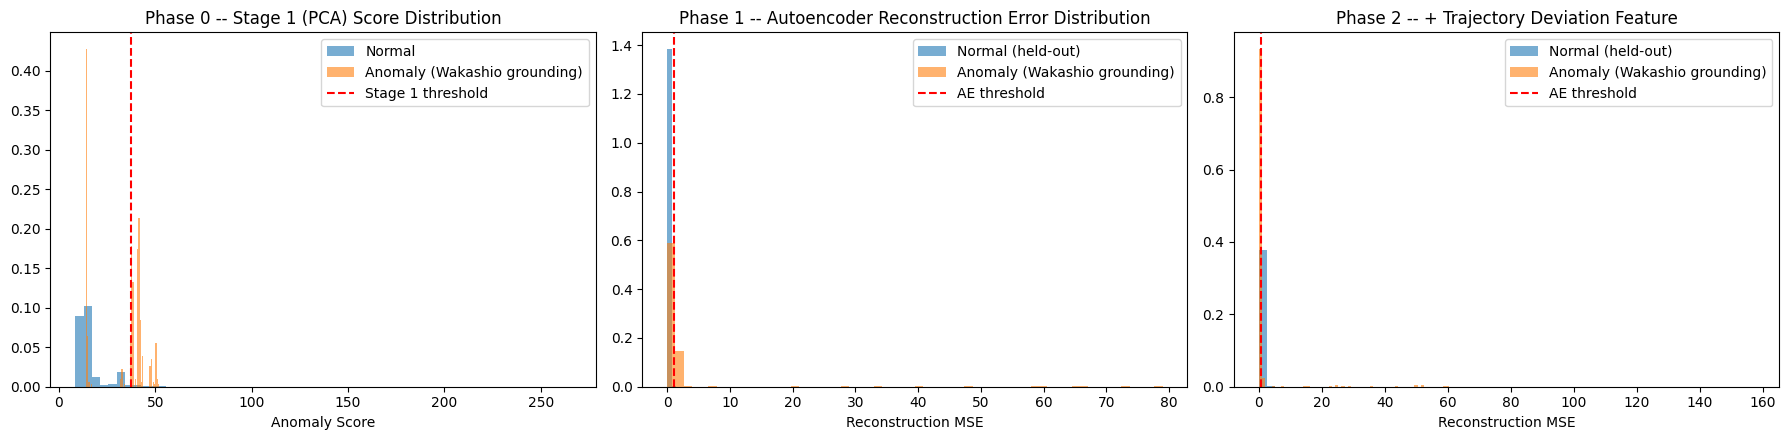

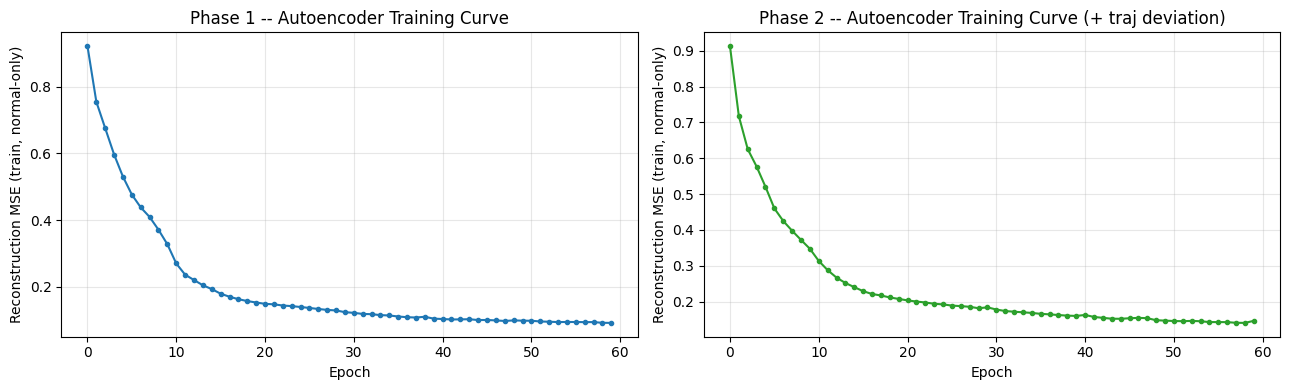

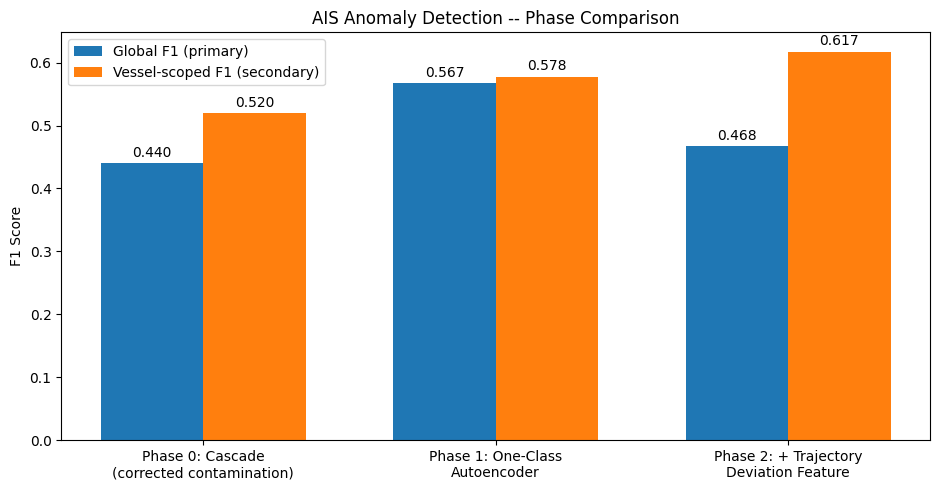

                  Phase 0: Cascade  Phase 1: Autoencoder  \
Global F1                   0.4402                0.5670   
Global Precision            0.3283                0.9299   
Global Recall               0.6680                0.4078   
Vessel-scoped F1            0.5195                0.5776   
ROC-AUC                     0.8918                0.7070   

                  Phase 2: + Traj Deviation  
Global F1                            0.4677  
Global Precision                     0.4753  
Global Recall                        0.4604  
Vessel-scoped F1                     0.6173  
ROC-AUC                              0.7204  


In [10]:
# CELL 7: Visualizations

def plot_score_distributions():
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    axes[0].hist(pca_scores[y_true==0], bins=60, alpha=0.6, label='Normal', density=True)
    axes[0].hist(pca_scores[y_true==1], bins=60, alpha=0.6, label='Anomaly (Wakashio grounding)', density=True)
    axes[0].axvline(stage1_thresh, color='red', linestyle='--', label='Stage 1 threshold')
    axes[0].set_title('Phase 0 -- Stage 1 (PCA) Score Distribution')
    axes[0].set_xlabel('Anomaly Score'); axes[0].legend()

    axes[1].hist(ae_scores[y_eval==0], bins=60, alpha=0.6, label='Normal (held-out)', density=True)
    axes[1].hist(ae_scores[y_eval==1], bins=60, alpha=0.6, label='Anomaly (Wakashio grounding)', density=True)
    axes[1].axvline(ae_thresh, color='red', linestyle='--', label='AE threshold')
    axes[1].set_title('Phase 1 -- Autoencoder Reconstruction Error Distribution')
    axes[1].set_xlabel('Reconstruction MSE'); axes[1].legend()

    axes[2].hist(ae_scores_p2[y_eval_p2==0], bins=60, alpha=0.6, label='Normal (held-out)', density=True)
    axes[2].hist(ae_scores_p2[y_eval_p2==1], bins=60, alpha=0.6, label='Anomaly (Wakashio grounding)', density=True)
    axes[2].axvline(ae_thresh_p2, color='red', linestyle='--', label='AE threshold')
    axes[2].set_title('Phase 2 -- + Trajectory Deviation Feature')
    axes[2].set_xlabel('Reconstruction MSE'); axes[2].legend()
    plt.tight_layout(); plt.show()


def plot_ae_training_curve():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(ae_loss_history, marker='o', markersize=3)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Reconstruction MSE (train, normal-only)')
    axes[0].set_title('Phase 1 -- Autoencoder Training Curve')
    axes[0].grid(alpha=0.3)

    axes[1].plot(ae_loss_history_p2, marker='o', markersize=3, color='tab:green')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Reconstruction MSE (train, normal-only)')
    axes[1].set_title('Phase 2 -- Autoencoder Training Curve (+ traj deviation)')
    axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_phase_comparison():
    phases = ['Phase 0: Cascade\n(corrected contamination)', 'Phase 1: One-Class\nAutoencoder',
              'Phase 2: + Trajectory\nDeviation Feature']
    global_f1 = [phase0_global['f1'], phase1_global['f1'], phase2_global['f1']]
    vessel_f1 = [phase0_vessel['f1'], phase1_vessel['f1'], phase2_vessel['f1']]

    x = np.arange(len(phases)); width = 0.35
    fig, ax = plt.subplots(figsize=(9.5, 5))
    ax.bar(x - width/2, global_f1, width, label='Global F1 (primary)')
    ax.bar(x + width/2, vessel_f1, width, label='Vessel-scoped F1 (secondary)')
    ax.set_xticks(x); ax.set_xticklabels(phases)
    ax.set_ylabel('F1 Score')
    ax.set_title('AIS Anomaly Detection -- Phase Comparison')
    ax.legend()
    for i, v in enumerate(global_f1):
        ax.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center')
    for i, v in enumerate(vessel_f1):
        ax.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center')
    plt.tight_layout(); plt.show()

    summary = pd.DataFrame({
        'Phase 0: Cascade': [phase0_global['f1'], phase0_global['precision'], phase0_global['recall'],
                              phase0_vessel['f1'], phase0_auc],
        'Phase 1: Autoencoder': [phase1_global['f1'], phase1_global['precision'], phase1_global['recall'],
                                  phase1_vessel['f1'], phase1_auc],
        'Phase 2: + Traj Deviation': [phase2_global['f1'], phase2_global['precision'], phase2_global['recall'],
                                       phase2_vessel['f1'], phase2_auc],
    }, index=['Global F1', 'Global Precision', 'Global Recall', 'Vessel-scoped F1', 'ROC-AUC'])
    print(summary.round(4))
    return summary


plot_score_distributions()
plot_ae_training_curve()
summary_table = plot_phase_comparison()


In [11]:
# CELL 8: Save models & deployment inference hooks

import joblib
joblib.dump(pca_model, 'ais_phase0_pca_stage1.joblib')
joblib.dump(lunar_model, 'ais_phase0_lunar_stage2.joblib')
torch.save(ae_model.state_dict(), 'ais_phase1_autoencoder.pth')
joblib.dump(scaler, 'ais_phase1_scaler.joblib')
torch.save(ae_model_p2.state_dict(), 'ais_phase2_autoencoder.pth')
joblib.dump(scaler_p2, 'ais_phase2_scaler.joblib')
summary_table.to_csv('ais_results_summary.csv')

best_phase = max(
    [('Phase 0', phase0_global['f1']), ('Phase 1', phase1_global['f1']), ('Phase 2', phase2_global['f1'])],
    key=lambda t: t[1]
)
print(f"\nBest performing phase on global F1: {best_phase[0]} ({best_phase[1]:.4f})")

print(f"\nThresholds to hardcode in deployment:")
print(f"  Stage 1 PCA threshold: {stage1_thresh:.6f}")
print(f"  Stage 2 LUNAR threshold: {stage2_thresh:.6f}")
print(f"  Phase 1 Autoencoder threshold: {ae_thresh:.6f}")
print(f"  Phase 2 Autoencoder threshold: {ae_thresh_p2:.6f}")


def predict_ais_anomaly_cascade(row_dict):
    """Phase 0 cascade inference. row_dict needs STAGE2_FEATURES keys."""
    x1 = np.array([[row_dict[f] for f in STAGE1_FEATURES]])
    s1_score = pca_model.decision_function(x1)[0]
    if s1_score >= stage1_thresh:
        return {'is_anomaly': True, 'stage': 1, 'score': float(s1_score)}
    x2 = np.array([[row_dict[f] for f in STAGE2_FEATURES]])
    s2_score = lunar_model.decision_function(x2)[0]
    return {'is_anomaly': bool(s2_score >= stage2_thresh), 'stage': 2, 'score': float(s2_score)}


def predict_ais_anomaly_autoencoder(row_dict):
    """Phase 1 autoencoder inference. row_dict needs STAGE2_FEATURES keys."""
    x = np.array([[row_dict[f] for f in STAGE2_FEATURES]])
    x_scaled = scaler.transform(x)
    ae_model.eval()
    with torch.no_grad():
        x_t = torch.tensor(x_scaled, dtype=torch.float32).to(device)
        recon = ae_model(x_t).cpu().numpy()
    score = float(np.mean((x_scaled - recon)**2))
    return {'is_anomaly': bool(score >= ae_thresh), 'score': score}


def predict_ais_anomaly_full(row_dict):
    """
    Phase 2 inference -- the recommended production function.
    row_dict needs STAGE3_FEATURES keys, INCLUDING 'traj_deviation_km'
    (get this from the trajectory prediction model's predict_next_position()
    output vs. the vessel's actual reported position -- see the trajectory
    prediction notebook's deployment hook).
    """
    x = np.array([[row_dict[f] for f in STAGE3_FEATURES]])
    x_scaled = scaler_p2.transform(x)
    ae_model_p2.eval()
    with torch.no_grad():
        x_t = torch.tensor(x_scaled, dtype=torch.float32).to(device)
        recon = ae_model_p2(x_t).cpu().numpy()
    score = float(np.mean((x_scaled - recon)**2))
    return {'is_anomaly': bool(score >= ae_thresh_p2), 'score': score}

print("Deployment helpers ready: `predict_ais_anomaly_cascade`, `predict_ais_anomaly_autoencoder`, `predict_ais_anomaly_full` (Phase 2, recommended).")



Best performing phase on global F1: Phase 1 (0.5670)

Thresholds to hardcode in deployment:
  Stage 1 PCA threshold: 37.276499
  Stage 2 LUNAR threshold: 0.058073
  Phase 1 Autoencoder threshold: 1.104481
  Phase 2 Autoencoder threshold: 0.502037
Deployment helpers ready: `predict_ais_anomaly_cascade`, `predict_ais_anomaly_autoencoder`, `predict_ais_anomaly_full` (Phase 2, recommended).
